In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pathlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
python_dir = pathlib.Path.cwd().parent.parent
data_dir = os.path.join(python_dir, 'ACSAF', 'METOPB_full_set.csv')

data = pd.read_csv(data_dir)

In [3]:
data.head()

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,date
0,2.576775e+13,1.013240e+13,NaN,NaN,NaN,NaN,2.538129e+15,NaN,NaN,1.904746e+14,292.67026,2.509943,-8.797272,8.637106,59.169120,31.335165,2017-11-25
1,3.932598e+13,9.583962e+12,NaN,NaN,NaN,NaN,2.625460e+15,NaN,NaN,1.585223e+14,292.26376,2.953442,0.883892,3.148954,59.274050,29.968560,2017-11-25
2,3.240653e+13,9.461983e+12,8.740034,31.97990,NaN,NaN,2.137938e+15,NaN,NaN,1.589865e+14,301.23334,2.977952,4.823585,7.494204,59.365433,28.580720,2017-11-25
3,2.675377e+13,9.587332e+12,10.056204,35.03932,NaN,NaN,2.554239e+15,NaN,NaN,1.572743e+14,295.99615,3.166650,-9.691098,15.375847,59.399986,27.305819,2017-11-25
4,3.397294e+13,9.764555e+12,NaN,NaN,NaN,NaN,2.143277e+15,NaN,NaN,1.689406e+14,293.37744,2.601635,-0.884305,94.365890,59.070830,31.547857,2017-11-25


In [4]:
data.tail()

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,date
2249933,5.155735e+13,1.438464e+13,NaN,NaN,NaN,NaN,1.595460e+15,1.801431e+15,1.970735e+15,1.675795e+14,428.50107,1.416726,-2.002236,8.607211,51.496574,19.091486,2026-02-08
2249934,2.486765e+13,1.266010e+13,NaN,NaN,NaN,NaN,1.294561e+15,NaN,NaN,1.633897e+14,418.97104,1.726417,1.466866,2.582030,51.438680,16.580502,2026-02-08
2249935,3.394596e+13,1.306851e+13,NaN,NaN,NaN,NaN,1.351132e+15,NaN,NaN,1.369905e+14,408.08258,1.836776,3.388359,3.552766,51.520470,15.440484,2026-02-08
2249936,3.157099e+13,1.391171e+13,NaN,NaN,NaN,NaN,1.415115e+15,NaN,NaN,1.493191e+14,413.03372,2.058753,-18.999784,12.233781,51.590767,14.308120,2026-02-08
2249937,4.226606e+13,1.431509e+13,NaN,NaN,NaN,NaN,1.516829e+15,1.579165e+15,2.307534e+15,1.440402e+14,423.22665,1.628642,3.094691,5.836656,51.480247,15.498205,2026-02-08


In [5]:
data['date_num'] = mdates.date2num(data['date'])

df = data[-20000:]

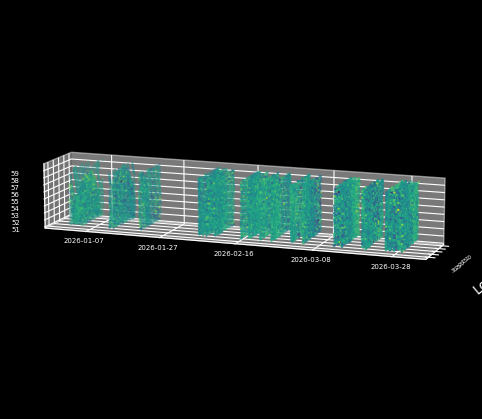

In [11]:
fig = plt.figure(figsize=(12, 4), dpi=100)
# ax = fig.add_subplot(111, projection='3d')
ax = fig.add_axes([0.05, 0, 0.9, 1], projection='3d')

sc = ax.scatter(df['lon'], df['date_num'], df['lat'], 
                c=df['BrO'], cmap='viridis', s=0.5)

ax.set_box_aspect((1, 6, 1)) 
ax.dist = 6

ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax.set_xlabel('Longitude')
ax.set_ylabel(None)
ax.set_zlabel('Latitude')
# plt.colorbar(sc, label='BrO Concentration', pad=0.1)

ax.zaxis.set_tick_params(labelsize=5)
ax.yaxis.set_tick_params(labelsize=5)
ax.xaxis.set_tick_params(labelsize=4)

fig.autofmt_xdate() 

ax.view_init(elev=12, azim=20)
# plt.savefig('temp.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [7]:
target_date = '2024-01-01'
day_df = data[data['date'] == target_date]

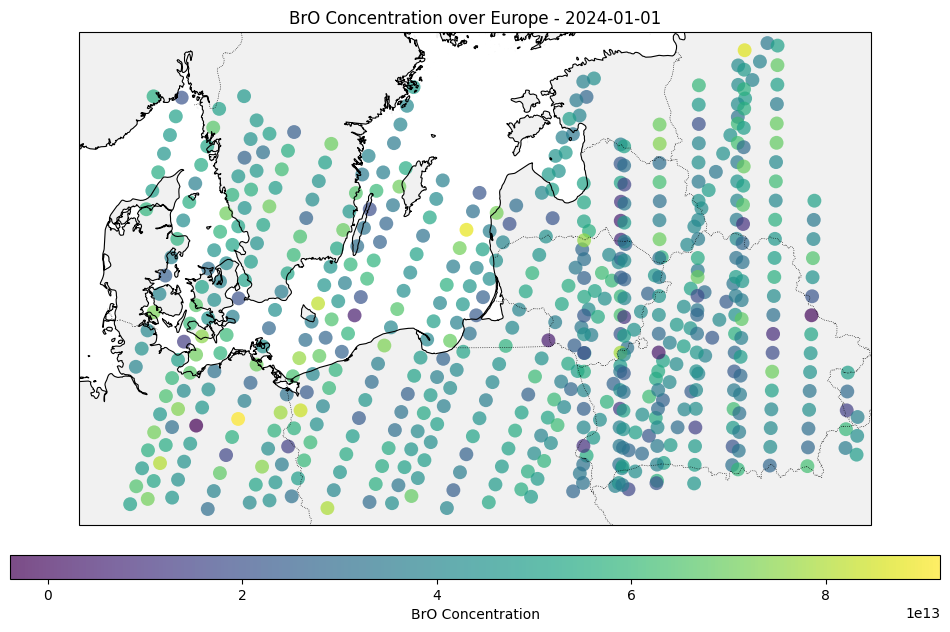

In [13]:
plt.style.use('default')
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=15, central_latitude=50))

# [Lon_min, Lon_max, Lat_min, Lat_max]
ax.set_extent([8, 32, 51, 59.5], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgrey', alpha=0.3)

sc = ax.scatter(day_df['lon'], day_df['lat'], c=day_df['BrO'], 
                cmap='viridis', s=100, transform=ccrs.PlateCarree(),
                edgecolor='none', alpha=0.7)

plt.colorbar(sc, label='BrO Concentration', orientation='horizontal', pad=0.05, aspect=40)
plt.title(f'BrO Concentration over Europe - {target_date}')
plt.savefig('temp2.png', bbox_inches='tight', dpi = 300)
plt.show()

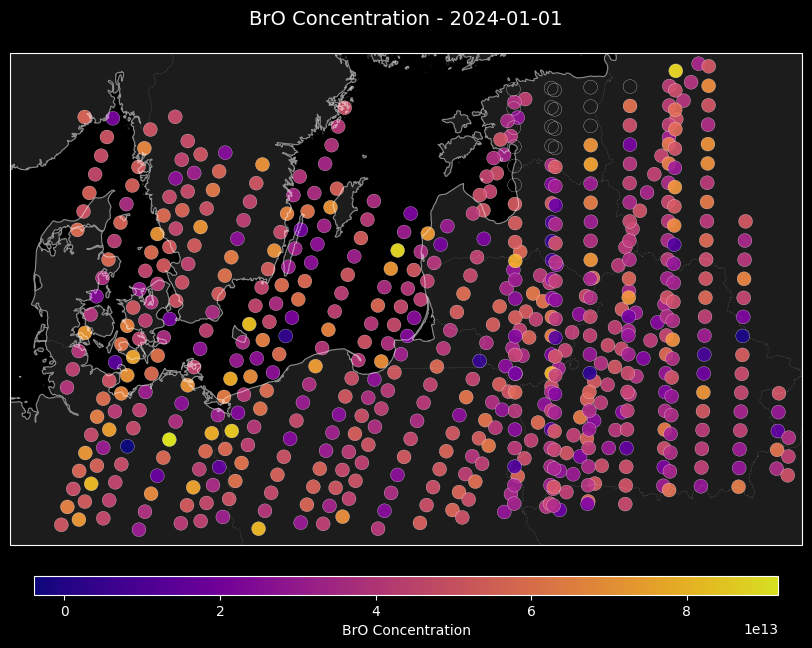

In [14]:
plt.style.use('dark_background')

fig = plt.figure(figsize=(12, 8))
fig.patch.set_facecolor('black')

ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=15, central_latitude=50))
ax.set_facecolor('black')

ax.set_extent([8, 32, 51, 59.5], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#1c1c1c', edgecolor='#333333')
ax.add_feature(cfeature.OCEAN, facecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='white', alpha=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='white', alpha=0.3)

sc = ax.scatter(day_df['lon'], day_df['lat'], c=day_df['BrO'], 
                cmap='plasma', s=100, transform=ccrs.PlateCarree(),
                edgecolor='white', linewidth=0.2, alpha=0.9)

cb = plt.colorbar(sc, label='BrO Concentration', orientation='horizontal', 
                  pad=0.05, aspect=40, shrink=0.8)
cb.outline.set_edgecolor('white')

plt.title(f'BrO Concentration - {target_date}', color='white', pad=20, fontsize=14)
plt.savefig('temp3.png', bbox_inches='tight', dpi = 300)
plt.show()